In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [2]:
data=pd.read_csv("./data/salary2.csv")

In [3]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


# 결측값 탐색

In [4]:
data.isna().sum()

age                  0
workclass         2799
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [5]:
# 개수가 적어서 삭제해도 됨 but 편향인지 확인할 것
data.isna().sum() / len(data) * 100

age               0.000000
workclass         5.730724
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
class             0.000000
dtype: float64

In [6]:
data['class'].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [7]:
# workclass의 결측값과 target의 관계
data[data['workclass'].isna()]





,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [8]:
# occupation의 결측값과 target의 관계
data[data['occupation'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [13]:
data[(data['workclass'].isna()) & (data['occupation'].isna()) & (data['class']==" >50K")]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
89,41,NaN,Masters,14,Married-civ-spouse,NaN,Wife,White,Female,7688,0,10,United-States,>50K
182,28,NaN,HS-grad,9,Married-civ-spouse,NaN,Own-child,White,Female,0,0,38,United-States,>50K
274,53,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,>50K
505,38,NaN,HS-grad,9,Married-civ-spouse,NaN,Wife,White,Female,0,1887,10,United-States,>50K
781,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,5178,0,40,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48278,60,NaN,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,0,0,12,United-States,>50K
48279,52,NaN,12th,8,Married-civ-spouse,NaN,Wife,Black,Female,0,0,40,United-States,>50K
48297,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,>50K
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K


In [14]:
# class가 >50K 일 때, occupation과 workclass가 Nan인 경우: 편향을 일으키는지 확인
265/11687 *100

2.267476683494481

In [12]:
data['class'].unique()

array([' <=50K', ' >50K'], dtype=object)

# 결측값의 비율이 약 7.5%이고, 삭제시 데이터 분포에 편향을 주지 않으므로 삭제

In [17]:
data=data.dropna()
data=data.reset_index(drop=True)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [19]:
data['class']=data['class'].apply(lambda x: 1 if x==' >50K' else 0)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


# 이상치 탐색

In [20]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week,class
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017,0.247844
std,13.217870,2.552881,7506.430084,404.956092,12.007508,0.431766
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [21]:
data['capital-gain'].value_counts()

capital-gain
0        41432
15024      498
7688       391
7298       351
99999      229
         ...  
7262         1
1731         1
22040        1
1639         1
2387         1
Name: count, Length: 121, dtype: int64

<Axes: ylabel='Frequency'>

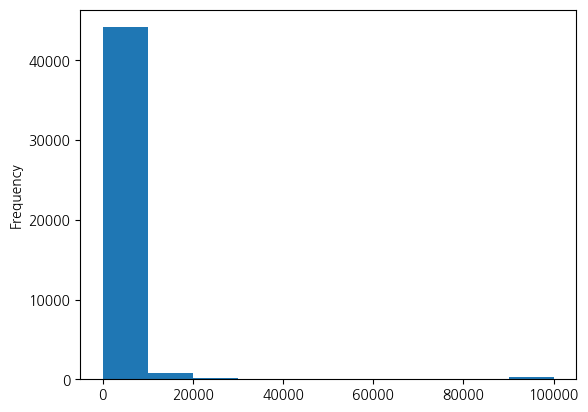

In [22]:
data['capital-gain'].plot(kind="hist")

# EDA

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education       45222 non-null  object
 3   education-num   45222 non-null  int64 
 4   marital-status  45222 non-null  object
 5   occupation      45222 non-null  object
 6   relationship    45222 non-null  object
 7   race            45222 non-null  object
 8   sex             45222 non-null  object
 9   capital-gain    45222 non-null  int64 
 10  capital-loss    45222 non-null  int64 
 11  hours-per-week  45222 non-null  int64 
 12  native-country  45222 non-null  object
 13  class           45222 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 4.8+ MB


In [24]:
obj_cols=data.select_dtypes(include='object')
num_cols=data.select_dtypes(exclude='object')

In [ ]:
ratio_result=data[['education','class']].groupby('education').mean().sort_values
ratio_result['class']>0.40

In [ ]:
#
ratio_result=data[['education','class']].groupby('education').mean().sort_values
ratio_result['class']>0.4

In [27]:
important_cols=[]
for col in obj_cols:
    print("="*30, col,"="*30 )
    print(col, obj_cols[col].nunique())
    print()
    print(obj_cols[col].value_counts)
    print()
    print(data[[col,'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result
    ratio_result=data[['education','class']].groupby('education').mean().sort_values
    ratio_result['class']>0.40
    print()

============================== workclass ==============================
workclass 7

<bound method IndexOpsMixin.value_counts of 0              Private
1              Private
2            Local-gov
3              Private
4              Private
             ...      
45217          Private
45218          Private
45219          Private
45220          Private
45221     Self-emp-inc
Name: workclass, Length: 45222, dtype: object>

                     class
workclass                 
Self-emp-inc      0.554070
Federal-gov       0.390469
Local-gov         0.295161
Self-emp-not-inc  0.278978
State-gov         0.267215
Private           0.217702
Without-pay       0.095238

============================== education ==============================
education 16

<bound method IndexOpsMixin.value_counts of 0                 11th
1              HS-grad
2           Assoc-acdm
3         Some-college
4                 10th
             ...      
45217       Assoc-acdm
45218          HS-grad
45219       

In [ ]:
finanl_cols=[]
for col in important_cols:
    if len(col) > 0:
        print(col.name)
        final_cols.append(col.name)
#    print(len(col))
final_cols

In [ ]:
data[['education','class']].groupby('education').mean().sort_values(by='class', ascending=False)

# 수치형 변수들 EDA

In [ ]:
for col in num_cols:
    print("="*30, col,"="*30 )
    print(col, num_cols[col].nunique())
    print()
    print(obj_cols[col].value_counts)
    print()
    print(data[[col,'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result
    ratio_result=data[['education','class']].groupby('education').mean().sort_values
    ratio_result['class']>0.40
    print()

In [30]:
data['education'].value_counts()

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64

In [31]:
data['education-num'].value_counts()

education-num
9     14783
10     9899
13     7570
14     2514
11     1959
7      1619
12     1507
6      1223
4       823
15      785
5       676
8       577
16      544
3       449
2       222
1        72
Name: count, dtype: int64

In [28]:
data_set1=data[final_cols]
data_set1=data_set1.drop("education", axis=1)
data_set1

NameError: name 'final_cols' is not defined

In [ ]:
X=pd.get_dummies(data_set1, drop_first=True)
y=data['class']

In [ ]:
from sklearn.model_selection import train_test_split(X, y, test_size=0.4, random_state=10)


In [ ]:
y_train.value_counts()

In [ ]:
from sklearn.tree import DecisionTreeClassifierci
from sklearn.metrics import accuracy_

# 모델 성능 튜닝(하이퍼파라미터 튜닝)

In [35]:
for i in range(1,11):
    dtc=DecisionTreeClassifier(max_depth=i, random_state=10)
    dtc.fit(X_train, y_train)
    pred=dtc.predict(X_test)
    print("="*30, i , "="*30)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

NameError: name 'DecisionTreeClassifier' is not defined

# 의사결정나무 시각화

In [36]:
from sklearn.tree import plot_tree

In [37]:
plt.figure(figsize=(20,20))
plot_tree(dtc, feature_names=dtc.feature_names_in_, fontsize=15, filled=True)
plt.show()

NameError: name 'dtc' is not defined

<Figure size 2000x2000 with 0 Axes>

In [38]:
dtc=DecisionTreeClassifier(max_depth=i, random_state=10)
dtc.fit(X_train, y_train)
pred=dtc.predict(X_test)
print("="*30, i , "="*30)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

NameError: name 'DecisionTreeClassifier' is not defined

In [ ]:
print(data[[col,'class']].groupby(col).mean().sort_values(by='class', ascending=False))
ratio_result=data[[col,'class']].groupby(col).mean().sort_values(by='class')

In [ ]:
data['education'].value_counts()

In [ ]:
data['education-num'].value_counts()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
y_train.value_counts()

In [ ]:
from sklearn.tree import DecisionTreeClassifiersion
pred=dtc.predict(X_test)
pri

# 의사결정나무 시각화

In [ ]:
from sklearn.tree import plot_tree

In [ ]:
plt.figure(figsize=(20,20))
plot_tree(dtc, feature_names=dtc.feature_names_in_, fontsize=15, filled=True)